In [ ]:
# question-1

import requests
import sqlite3
import os

In [ ]:
url = "https://openlibrary.org/search.json"

params = {
    "q": "fantasy",
    "limit": 10,
    "fields": "key,title,author_name,first_publish_year"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [ ]:
data = response.json()

print(data.keys())

dict_keys(['numFound', 'start', 'numFoundExact', 'num_found', 'documentation_url', 'q', 'offset', 'docs'])


In [ ]:
print(data["docs"][0])

{'author_name': ['Carole Mortimer'], 'first_publish_year': 1983, 'key': '/works/OL3775422W', 'title': 'Fantasy Girl'}


In [ ]:
print("Key:", data["docs"][0].get("key"))
print("Title:", data["docs"][0].get("title"))
print("Author:", data["docs"][0].get("author_name"))
print("Year:", data["docs"][0].get("first_publish_year"))

Key: /works/OL3775422W
Title: Fantasy Girl
Author: ['Carole Mortimer']
Year: 1983


In [ ]:
rows = []
skipped = 0

for raw in data["docs"]:
    source_id = raw.get("key")
    title = raw.get("title")

    if not source_id or not title:
        skipped += 1
        continue

    authors = raw.get("author_name") or []
    author = ", ".join(authors) if authors else "Unknown"

    year = raw.get("first_publish_year")
    year = int(year) if isinstance(year, (int, float)) else None

    rows.append((source_id, title, author, year))

print("Normalised:", len(rows), "book(s)")
print("Skipped:", skipped)

Normalised: 10 book(s)
Skipped: 0


In [ ]:
for row in rows:
    print(row)

('/works/OL3775422W', 'Fantasy Girl', 'Carole Mortimer', 1983)
('/works/OL3759099W', 'Her Christmas Fantasy', 'Penny Jordan', 1996)
('/works/OL733144W', 'My Secret Garden', 'Nancy Friday', 1973)
('/works/OL2959228W', 'Fantasy', 'Emma Darcy', 1985)
('/works/OL14873636W', 'Fantasy in death', 'Nora Roberts, Susan Ericksen', 2010)
('/works/OL34774028W', 'Powerless', 'Lauren Roberts', 2023)
('/works/OL15493152W', 'The Kingdom of Fantasy', 'Elisabetta Dami, David Nel·lo, Larry Keys, Titi Plumederat, Koldo Biguri', 2005)
('/works/OL733159W', 'Forbidden Flowers', 'Nancy Friday', 1975)
('/works/OL3522021W', 'Fantasy Lover', 'Sherrilyn Kenyon', 2002)
('/works/OL15437W', 'Lilith', 'George MacDonald', 1895)


In [ ]:
conn = sqlite3.connect("books.db")
cursor = conn.cursor()

print("Connected to books.db")

Connected to books.db


In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS books (
    source_id        TEXT PRIMARY KEY,
    title            TEXT NOT NULL,
    author           TEXT NOT NULL DEFAULT 'Unknown',
    publication_year INTEGER,
    fetched_at       TEXT NOT NULL DEFAULT (datetime('now'))
)
""")

print("Books table created")

Books table created


In [ ]:
cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_books_author
ON books(author)
""")

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_books_year
ON books(publication_year)
""")

print("Indexes created")

Indexes created


In [ ]:
sql = """
INSERT INTO books (source_id, title, author, publication_year)
VALUES (?, ?, ?, ?)
ON CONFLICT(source_id) DO UPDATE SET
    title = excluded.title,
    author = excluded.author,
    publication_year = excluded.publication_year,
    fetched_at = datetime('now')
"""

with conn:
    conn.executemany(sql, rows)

print("Upserted", len(rows), "record(s) into books.db")

Upserted 10 record(s) into books.db


In [ ]:
cursor.execute("""
SELECT source_id, title, author, publication_year
FROM books
ORDER BY publication_year IS NULL, publication_year
""")

stored_rows = cursor.fetchall()

for row in stored_rows:
    print(row)

('/works/OL15437W', 'Lilith', 'George MacDonald', 1895)
('/works/OL733144W', 'My Secret Garden', 'Nancy Friday', 1973)
('/works/OL733159W', 'Forbidden Flowers', 'Nancy Friday', 1975)
('/works/OL3775422W', 'Fantasy Girl', 'Carole Mortimer', 1983)
('/works/OL2959228W', 'Fantasy', 'Emma Darcy', 1985)
('/works/OL3759099W', 'Her Christmas Fantasy', 'Penny Jordan', 1996)
('/works/OL3522021W', 'Fantasy Lover', 'Sherrilyn Kenyon', 2002)
('/works/OL15493152W', 'The Kingdom of Fantasy', 'Elisabetta Dami, David Nel·lo, Larry Keys, Titi Plumederat, Koldo Biguri', 2005)
('/works/OL14873636W', 'Fantasy in death', 'Nora Roberts, Susan Ericksen', 2010)
('/works/OL34774028W', 'Powerless', 'Lauren Roberts', 2023)


In [ ]:
total = len(stored_rows)
with_year = sum(row[3] is not None for row in stored_rows)

years = [row[3] for row in stored_rows if row[3] is not None]

print("\nTotal stored:", total)
print("With year:", with_year)

if years:
    print("Year range:", min(years), "-", max(years))


Total stored: 10
With year: 10
Year range: 1895 - 2023


In [ ]:
conn.close()

In [ ]:
#question-3

csv_content = """name,email,age,city
Diya Patel,diya.patel@example.com,31,Hyderabad
Aarav Sharma,aarav.sharma@example.com,40,Kolkata
Kabir Nair,kabir.nair@example.com,abc,Kochi
Meera Krishnan,meera.krishnan@example.com,27,Delhi
Rohan Iyer,rohan.iyer@example.com,25,Chennai
Vihaan Gupta,vihaan.gupta@example.com,,Jaipur
Zara D'Souza,zara.dsouza@example.com,26,Goa
"""

with open("users.csv", "w", encoding="utf-8") as file:
    file.write(csv_content)

print("users.csv created successfully")

users.csv created successfully


In [ ]:
import csv

with open("users.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        print(row)

{'name': 'Diya Patel', 'email': 'diya.patel@example.com', 'age': '31', 'city': 'Hyderabad'}
{'name': 'Aarav Sharma', 'email': 'aarav.sharma@example.com', 'age': '40', 'city': 'Kolkata'}
{'name': 'Kabir Nair', 'email': 'kabir.nair@example.com', 'age': 'abc', 'city': 'Kochi'}
{'name': 'Meera Krishnan', 'email': 'meera.krishnan@example.com', 'age': '27', 'city': 'Delhi'}
{'name': 'Rohan Iyer', 'email': 'rohan.iyer@example.com', 'age': '25', 'city': 'Chennai'}
{'name': 'Vihaan Gupta', 'email': 'vihaan.gupta@example.com', 'age': '', 'city': 'Jaipur'}
{'name': "Zara D'Souza", 'email': 'zara.dsouza@example.com', 'age': '26', 'city': 'Goa'}


In [ ]:
import sqlite3

conn = sqlite3.connect("users.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id         INTEGER PRIMARY KEY AUTOINCREMENT,
    name       TEXT NOT NULL,
    email      TEXT NOT NULL UNIQUE COLLATE NOCASE,
    age        INTEGER,
    city       TEXT,
    created_at TEXT NOT NULL DEFAULT (datetime('now')),
    updated_at TEXT NOT NULL DEFAULT (datetime('now'))
)
""")

print("Database and users table created successfully")

Database and users table created successfully


In [ ]:
import re

valid_rows = []
rejected_rows = []

with open("users.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for line_no, row in enumerate(reader, start=2):

        name = row["name"].strip()
        email = row["email"].strip().lower()
        age_text = row["age"].strip()
        city = row["city"].strip()


        if not name:
            rejected_rows.append((line_no, "missing name"))
            continue

        if not email:
            rejected_rows.append((line_no, "missing email"))
            continue


        if not re.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", email):
            rejected_rows.append((line_no, f"malformed email: '{email}'"))
            continue


        if age_text == "":
            age = None
        else:
            try:
                age = int(age_text)
            except ValueError:
                age = None
                print(f"WARNING | line {line_no}: unparseable age '{age_text}' -> stored as NULL")

        valid_rows.append((name, email, age, city))

print("\nValid rows:", len(valid_rows))
print("Rejected rows:", len(rejected_rows))

for line_no, reason in rejected_rows:
    print(f"Rejected line {line_no}: {reason}")

WARNING | line 4: unparseable age 'abc' -> stored as NULL

Valid rows: 7
Rejected rows: 0


In [ ]:
sql = """
INSERT INTO users (name, email, age, city)
VALUES (?, ?, ?, ?)
ON CONFLICT(email) DO UPDATE SET
    name = excluded.name,
    age = excluded.age,
    city = excluded.city,
    updated_at = datetime('now')
"""

with conn:
    conn.executemany(sql, valid_rows)

print("Inserted/updated", len(valid_rows), "row(s)")

Inserted/updated 7 row(s)


In [ ]:
cursor.execute("""
SELECT id, name, email, age, city
FROM users
ORDER BY id
""")

stored_users = cursor.fetchall()

print("\n--- USERS TABLE ---")
print(f"{'ID':<5}{'NAME':<20}{'EMAIL':<35}{'AGE':<6}{'CITY'}")
print("-" * 80)

for user in stored_users:
    age = user[3] if user[3] is not None else "-"
    print(f"{user[0]:<5}{user[1]:<20}{user[2]:<35}{age:<6}{user[4]}")


--- USERS TABLE ---
ID   NAME                EMAIL                              AGE   CITY
--------------------------------------------------------------------------------
1    Diya Patel          diya.patel@example.com             31    Hyderabad
2    Aarav Sharma        aarav.sharma@example.com           40    Kolkata
3    Kabir Nair          kabir.nair@example.com             -     Kochi
4    Meera Krishnan      meera.krishnan@example.com         27    Delhi
5    Rohan Iyer          rohan.iyer@example.com             25    Chennai
6    Vihaan Gupta        vihaan.gupta@example.com           -     Jaipur
7    Zara D'Souza        zara.dsouza@example.com            26    Goa


In [ ]:
print("\n--- IMPORT SUMMARY ---")
print("Read:", len(valid_rows) + len(rejected_rows))
print("Valid:", len(valid_rows))
print("Rejected:", len(rejected_rows))
print("Written:", len(stored_users))


--- IMPORT SUMMARY ---
Read: 7
Valid: 7
Rejected: 0
Written: 7


In [ ]:
conn.close()

In [1]:
#question 2

import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://gist.githubusercontent.com/keizer619/9b4439380c0d3925a3ba94aef55818a1/raw/sample.json"

response = requests.get(url)

print("Status code:", response.status_code)

Status code: 200


In [3]:
import json

data = [
    json.loads(line)
    for line in response.text.strip().splitlines()
]

print("Number of students:", len(data))
print(data[0])

Number of students: 200
{'_id': 0, 'name': 'aimee Zank', 'scores': [{'score': 1.463179736705023, 'type': 'exam'}, {'score': 11.78273309957772, 'type': 'quiz'}, {'score': 35.8740349954354, 'type': 'homework'}]}


In [4]:
student_scores = []

for student in data:
    exam_score = next(
        (item["score"] for item in student["scores"]
         if item["type"] == "exam"),
        None
    )

    student_scores.append({
        "student": student["name"],
        "score": exam_score
    })

df = pd.DataFrame(student_scores)

print(df.head())

            student      score
0        aimee Zank   1.463180
1  Aurelia Menendez  60.060451
2       Corliss Zuk  67.030771
3        Bao Ziglar  71.643439
4  Zachary Langlais  78.683851


In [5]:
df["score"] = pd.to_numeric(df["score"], errors="coerce")

missing = df["score"].isna().sum()
df = df.dropna(subset=["score"])

out_of_range = ((df["score"] < 0) | (df["score"] > 100)).sum()
df = df[(df["score"] >= 0) & (df["score"] <= 100)]

print("Data Cleaning Report")
print("Missing scores removed:", missing)
print("Out-of-range scores removed:", out_of_range)
print("Valid records:", len(df))

Data Cleaning Report
Missing scores removed: 0
Out-of-range scores removed: 0
Valid records: 200


In [6]:
average_score = df["score"].mean()

print("Average Exam Score:", round(average_score, 2))

Average Exam Score: 48.67


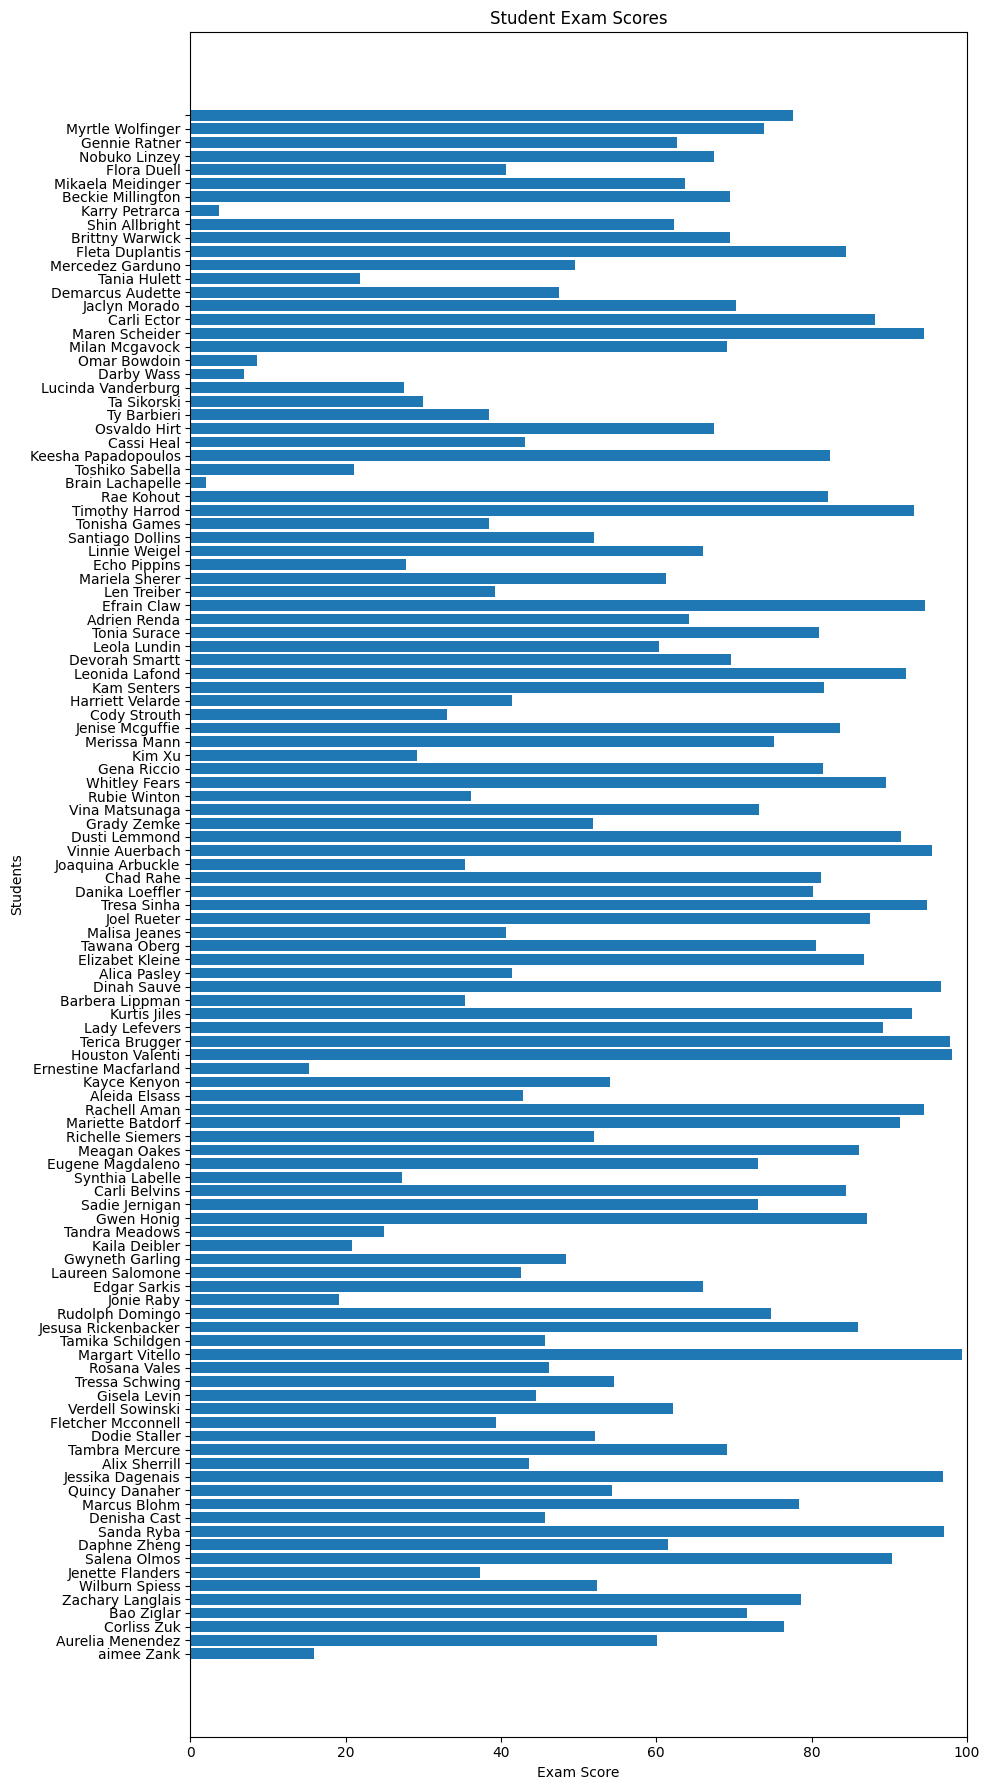

In [8]:
plt.figure(figsize=(10, 18))

plt.barh(df["student"], df["score"])

plt.xlabel("Exam Score")
plt.ylabel("Students")
plt.title("Student Exam Scores")

plt.xlim(0, 100)
plt.tight_layout()
plt.show()